In [1]:
import sys
import numpy as np

# make the uploaded toolbox importable
sys.path.append("/mnt/data")
from mi_toolbox_v2 import make_regression_1d, MSE, train_linear_model_gd

In [9]:
# ------------------------------------------------------------
# 1) Data (toolbox gives X_row: shape (p,2) = [1, x], and y: (p,))
# ------------------------------------------------------------
X_row, y = make_regression_1d(n=120, noise=0.3, outliers=0, seed=1)
p = len(y)

# Convert to the PDF orientation: X_col is shape (2,p)
# (each column is x^(alpha) = [1, x_alpha]^T )
X = X_row.T

In [3]:
# ------------------------------------------------------------
# 2) Model + quadratic cost (PDF: E_T = (1/(2p)) || w^T X - y ||^2 )
# ------------------------------------------------------------
def predict(w, X):
    # w: (2,), X: (2,p) -> y_pred: (p,)
    return w @ X

def cost(w, X, y):
    r = predict(w, X) - y
    return 0.5 / len(y) * float(np.sum(r * r))

In [4]:
# ------------------------------------------------------------
# 3) Gradient and Hessian (PDF matrix form)
#   g = (1/p) (X X^T w - X y)
#   H = (1/p) X X^T
# ------------------------------------------------------------
def grad(w, X, y):
    return (X @ (X.T @ w) - X @ y) / len(y)

def hess(X, p):
    return (X @ X.T) / p

In [5]:
# ------------------------------------------------------------
# 4) Closed-form minimizer (normal equation in PDF orientation)
#   stationary point: X X^T w* = X y
#   w* = (X X^T)^(-1) X y
# ------------------------------------------------------------
def w_star_closed_form(X, y):
    A = X @ X.T      # (2,2)
    b = X @ y        # (2,)
    return np.linalg.solve(A, b)

In [7]:
# ------------------------------------------------------------
# 5) Ridge-regularized solution (PDF: w* = (X X^T + p λ I)^(-1) X y )
# ------------------------------------------------------------
def w_star_ridge(X, y, lam):
    p = len(y)
    A = X @ X.T + (p * lam) * np.eye(X.shape[0])
    b = X @ y
    return np.linalg.solve(A, b)

In [6]:
# ------------------------------------------------------------
# 6) Sanity check: finite-difference gradient (your “try w±ε” intuition)
# ------------------------------------------------------------
def grad_fd(w, X, y, eps=1e-6):
    g = np.zeros_like(w, dtype=float)
    for i in range(len(w)):
        wp = w.copy(); wp[i] += eps
        wm = w.copy(); wm[i] -= eps
        g[i] = (cost(wp, X, y) - cost(wm, X, y)) / (2 * eps)
    return g

In [11]:
# Run everything
w0 = np.zeros(2)

H = hess(X, p)
w_star = w_star_closed_form(X, y)
w_ridge = w_star_ridge(X, y, lam=0.1)

print("w0         =", w0)
print("grad(w0)   =", grad(w0, X, y))
print("H          =\n", H)

print("\nw* (closed)=", w_star, "  cost=", cost(w_star, X, y))
print("grad(w*)   =", grad(w_star, X, y), " (should be ~0)")

print("\nFD grad(w*)=", grad_fd(w_star, X, y), " (finite-diff check)")

print("\nw* ridge   =", w_ridge, "  cost=", cost(w_ridge, X, y))

w0         = [0. 0.]
grad(w0)   = [-1.05473092 -4.06483233]
H          =
 [[1.         0.04660276]
 [0.04660276 1.99200223]]

w* (closed)= [0.96068183 2.01810111]   cost= 0.043040614121645934
grad(w*)   = [-2.36847579e-16  4.73695157e-16]  (should be ~0)

FD grad(w*)= [0. 0.]  (finite-diff check)

w* ridge   = [0.87735543 1.92348989]   cost= 0.05579514322690066


In [12]:
# ------------------------------------------------------------
# 7) Compare with your toolbox GD (same objective: MSE = 0.5*mean(r^2))
# ------------------------------------------------------------
w_gd, history = train_linear_model_gd(X_row, y, loss_fn=MSE(), lr=0.2, epochs=5000, seed=0)

print("\nToolbox GD =", w_gd, "  final loss=", history[-1])
print("Closed-form=", w_star, "  (should match GD up to tiny numeric error)")


Toolbox GD = [0.96068183 2.01810111]   final loss= 0.04304061412164594
Closed-form= [0.96068183 2.01810111]   (should match GD up to tiny numeric error)


# 4.1

Als erstes erstellen wir ein Datenset um überhaupt eine Neuronales Netz trainieren zu können.

In [47]:
import numpy as np

# 2 inputs: x1, x2
X = np.array([
    [-2.0, -1.0],
    [-2.0,  1.0],
    [-1.0, -2.0],
    [-1.0,  2.0],
    [ 0.0, -1.0],
    [ 0.0,  1.0],
    [ 1.0, -2.0],
    [ 1.0,  2.0],
    [ 2.0, -1.0],
    [ 2.0,  1.0],
], dtype=float)

# Ground truth mapping (unknown to your regressor):
# y1 =  2*x1 - 1*x2 + 0.5
# y2 = -1*x1 + 3*x2 - 1.0
# plus small noise
rng = np.random.default_rng(0)
noise = 0.05 * rng.normal(size=(len(X), 2))

del(Y_T)
Y_T = np.column_stack([
    2*X[:,0] - 1*X[:,1] + 0.5,
   -1*X[:,0] + 3*X[:,1] - 1.0
]) + noise

print("X shape:", X.shape)  # (10,2)
print("Y shape:", Y_T.shape)  # (10,2)
print("\nFirst 5 rows:\n", np.hstack([X, Y_T]))


X shape: (10, 2)
Y shape: (10, 2)

First 5 rows:
 [[-2.         -1.         -2.49371349 -2.00660524]
 [-2.          1.         -4.46797887  4.00524501]
 [-1.         -2.          0.47321653 -5.98192025]
 [-1.          2.         -3.4348      6.04735405]
 [ 0.         -1.          1.46481324 -4.06327107]
 [ 0.          1.         -0.53116372  2.0020663 ]
 [ 1.         -2.          4.38374846 -8.01093958]
 [ 1.          2.          0.43770445  3.96338663]
 [ 2.         -1.          5.47278705 -6.01581501]
 [ 2.          1.          3.52058153  0.05212567]]


Nun brauche ich ein Neurnales Netz mit Linearen Aktivierungsfunktionen

In [ ]:
from mi_toolbox_v2 import ConnectionistNeuron

neurons = []
for neuron in range(2):
    neuron = ConnectionistNeuron(n_features=2, activation="linear", lr=0.1, seed=0)
    neurons.append(neuron)

In [71]:
Y = np.column_stack([n.forward(X) for n in neurons])      # (p,2)
W = np.column_stack([n.w for n in neurons])               # (2,2) columns=neurons
b = np.array([n.b for n in neurons])                      # (2,)

print(Y.shape)
print(W)

(10, 2)
[[ 0.0012573   0.0012573 ]
 [-0.00132105 -0.00132105]]


Die Errorfunktion nehme ich aus der Toolbox

In [54]:
from mi_toolbox_v2 import MSE

mse = MSE()
E_T = mse(Y, Y_T)
E_T

(8.282812959754287,
 array([ 0.124626  ,  0.10013848,  0.22346818, -0.20045722, -0.02359477,
         0.29902996,  0.17193497, -0.30243694, -0.07304888,  0.20322323,
         0.02649851, -0.1002951 , -0.21911818,  0.40035201, -0.02181917,
        -0.19823538, -0.27344438,  0.30072151, -0.17583729, -0.00254661]))

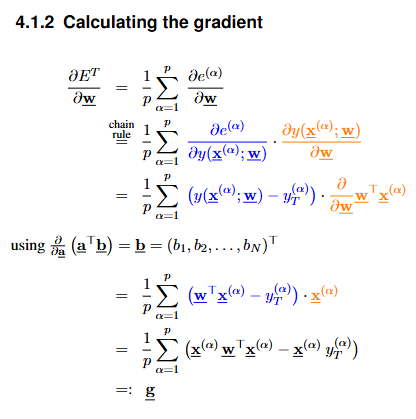

In [64]:
def grad_W_b(X, W, b, Y_T):
    p = X.shape[0]
    R = (X @ W + b) - Y_T          # (p,2)
    gW = X.T @ R / p               # (2,2)
    gb = R.sum(axis=0) / p         # (2,)
    return gW, gb


In [67]:
grad_W_b(X, W, b, Y_T)

(array([[-3.96680122,  2.0062791 ],
        [ 2.16015059, -6.61813924]]),
 array([-0.48251952,  1.00083735]))

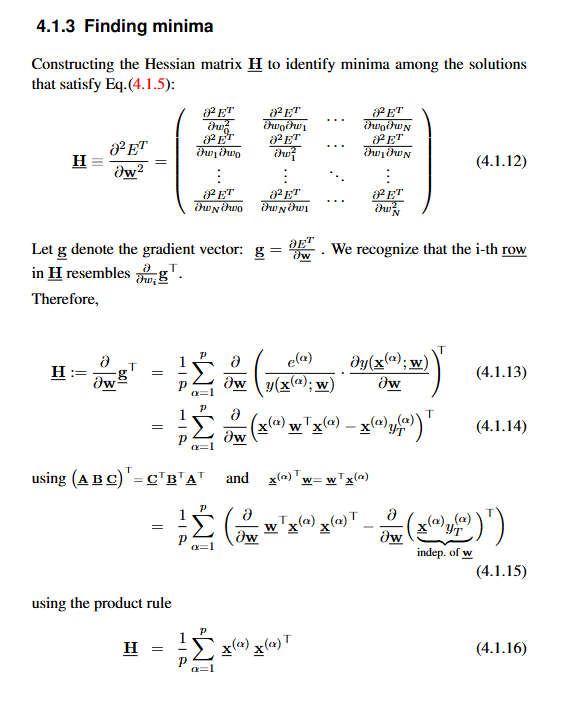

In [68]:
p = X.shape[0]
print(p)
H = (X.T @ X) / p   # (2,2)
print(H)

10
[[2.  0. ]
 [0.  2.2]]


In [ ]:
Xb = np.hstack([np.ones((p,1)), X])  # (p,3)
print(Xb)
Hb = (Xb.T @ Xb) / p                 # (3,3)

[[ 1. -2. -1.]
 [ 1. -2.  1.]
 [ 1. -1. -2.]
 [ 1. -1.  2.]
 [ 1.  0. -1.]
 [ 1.  0.  1.]
 [ 1.  1. -2.]
 [ 1.  1.  2.]
 [ 1.  2. -1.]
 [ 1.  2.  1.]]


### Lass mich das mal ausprobieren

In [ ]:
for i in range(100):
    lr = 0.1
    Y = np.column_stack([n.forward(X) for n in neurons])
    W = np.column_stack([n.w for n in neurons])               # (2,2) columns=neurons
    b = np.array([n.b for n in neurons])
    print(mse(Y, Y_T)[0])
    g_W, g_b = grad_W_b(X, W, b, Y_T)
    W -= lr * g_W
    b -= lr * g_b
    # print(W)
    for j, n in enumerate(neurons):
        n.w = W[j]
        n.b = b[j]
    # print(b)

8.286780026891918
5.183229990842359
3.2534989238705605
2.052509520836063
1.302135008342232
0.8322086622626508
0.536436181618758
0.3494364810499464
0.2304226070044555
0.1540956033128384
0.10471552037806912
0.07238978318479311
0.05099274739670977
0.036594665378495775
0.02678064733919729
0.01995244517488239
0.015139007101036234
0.011667768361256305
0.009136420262513576
0.0072484107533079215
0.005829735923707813
0.0047417229410743455
0.003904668996956885
0.0032492787003000913
0.002736445915457858
0.0023291723299074816
0.0020068303167769604
0.0017484779892194724
0.0015424874565985386
0.0013764460476734905
0.0012434378804224168
0.0011358564205208306
0.0010494249152202568
0.0009793754019775136
0.000922993146416448
0.0008772450998752424
0.0008403792802832158
0.0008104480947762249
0.000786309438797259
0.0007667053100531482
0.0007508867483062897
0.0007380381472764948
0.0007276666949264739
0.0007192423515542974
0.0007124402494905113
0.0007069154003909367
0.000702453446908059
0.0006988296141619906

## Cool jetzt mit komplexeren Datensätzen


In [81]:
import numpy as np

def make_nonlinear_dataset_A(n=2000, d=6, k=3, noise=0.15, seed=0):
    """
    Smooth nonlinear: sin/cos, polynomials, cross-terms, exp bump.
    X: (n,d), Y: (n,k)
    """
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2.0, 2.0, size=(n, d))

    x1, x2, x3, x4, x5, x6 = X[:,0], X[:,1], X[:,2], X[:,3], X[:,4], X[:,5]

    y1 = 0.9*np.sin(1.7*x1) + 0.35*(x2**2) - 0.6*(x3*x4) + np.exp(-x5**2) + 0.1*x6
    y2 = 0.7*np.cos(1.3*x2) + 0.25*(x1*x4) - 0.2*(x3**3) + 0.3*np.tanh(2.0*x6)
    y3 = 0.5*np.sin(x1 + x2) + 0.4*(x5*x6) - 0.3*(x2*x3) + 0.15*(x4**2)

    Y = np.column_stack([y1, y2, y3])

    # Add Gaussian noise
    Y += noise * rng.normal(size=Y.shape)

    return X, Y

In [82]:
X, Y_T = make_nonlinear_dataset_A(n=1000, d=6, k=3, noise=0.12, seed=0)
print(X.shape, Y_T.shape)  # (1000,6) (1000,3)
print(Y_T[:3])

(1000, 6) (1000, 3)
[[-0.81721687  1.66599159  0.59427823]
 [ 0.66181117  0.20880133 -0.06041196]
 [ 2.47163265 -0.80543705  0.72570697]]


In [83]:
import numpy as np
from mi_toolbox_v2 import ConnectionistNeuron

# X: (p,d), Y_T: (p,k)
p, d = X.shape
k = Y_T.shape[1]

# init k neurons (one per output)
neurons = [
    ConnectionistNeuron(n_features=d, activation="linear", lr=0.1, seed=j)
    for j in range(k)
]

def loss_multi(X, W, b, Y_T):
    R = (X @ W + b) - Y_T
    # consistent with your gradient that divides by p (sum over outputs per sample)
    return 0.5 * np.sum(R**2) / p

def grad_W_b(X, W, b, Y_T):
    p = X.shape[0]
    R = (X @ W + b) - Y_T          # (p,k)
    gW = X.T @ R / p               # (d,k)
    gb = R.sum(axis=0) / p         # (k,)
    return gW, gb

for i in range(2000):
    lr = 0.05

    # build W,b from neurons (columns = neurons)
    W = np.column_stack([n.w for n in neurons])   # (d,k)
    b = np.array([n.b for n in neurons])          # (k,)

    if i % 200 == 0:
        print("loss:", loss_multi(X, W, b, Y_T))

    gW, gb = grad_W_b(X, W, b, Y_T)

    W -= lr * gW
    b -= lr * gb

    # write back correctly: neuron j gets column j
    for j, n in enumerate(neurons):
        n.w = W[:, j]
        n.b = float(b[j])


loss: 1.7726876711669408
loss: 1.0573509199248463
loss: 1.0573509191714714
loss: 1.0573509191714714
loss: 1.0573509191714714
loss: 1.0573509191714714
loss: 1.0573509191714714
loss: 1.0573509191714714
loss: 1.0573509191714714
loss: 1.0573509191714714
